In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

In [2]:
from src.code import Roost

import numpy as np
import matplotlib.pyplot as plt

Model

This model explore how call range affects departure timing and how many jackdaws leave together.

In model A ,a bird takes off the total call signal received in current step reaches its threshold.
    Assumptions
        * take off threshold: 1 signal unit
        * call range: start with 8 surrounding cells and increases 1 cell in every 2 time step, up to 24 cells.
        * birds takes off: when its received signal is oqual or greater than the threshold. And take off bird will stop calling.
        * In a 30*30 roost has 450 jackdaws.


In [3]:
np.random.seed(47)

roost = Roost(n=30, number_of_birds=450)
print(len(roost.agents))

450


In [4]:
for bird in roost.agents:
    bird.call_cells = 8
    bird.threshold = 1

    if np.random.random() < 0.1:
        bird.calling = True

roost.update_calls()
roost.update_takeoffs()

In [5]:
def draw_roost(roost):
    
    plt.figure(figsize=(7,7))

    taking_off = 0

    for bird in roost.agents:
        row,col = bird.loc

        if bird.state == "taking_off":
            color = "orange"
            taking_off += 1

        elif bird.calling:
            color = "red"

        else:
            color = "black"

        plt.plot(
            col + 0.5,
            row + 0.5,
            "o",
            color=color,
            markersize=4)

    plt.xlim(0,roost.n)
    plt.ylim(0,roost.n)
    plt.gca().set_aspect("equal")
    plt.xlabel("Col(forest)")
    plt.ylabel("Row(forest)")
    plt.plot([],[],"o",color="black",label="Quiet jackdaw")
    plt.plot([],[],"o",color="red",label="Calling jackdaw(still in roost,not take off)")
    plt.plot([],[],"o",color="orange",label="Take off jackdaw")
    plt.legend(loc="upper left",bbox_to_anchor=(1.02,1))
    plt.title(f"Taking off:{taking_off}/{len(roost.agents)}")
    plt.show()

The title shows how many jackdaws have take off so far in total population.

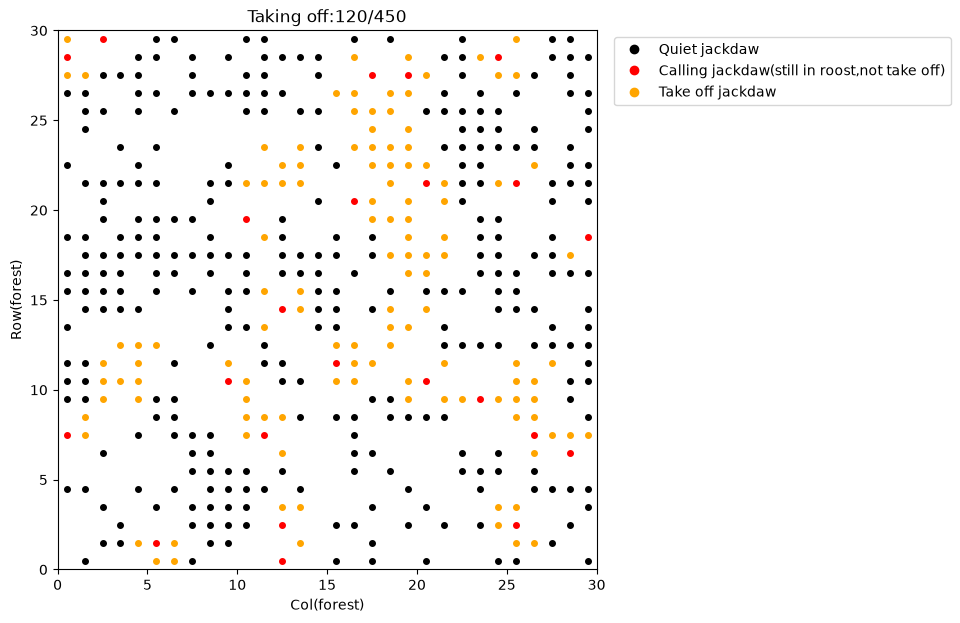

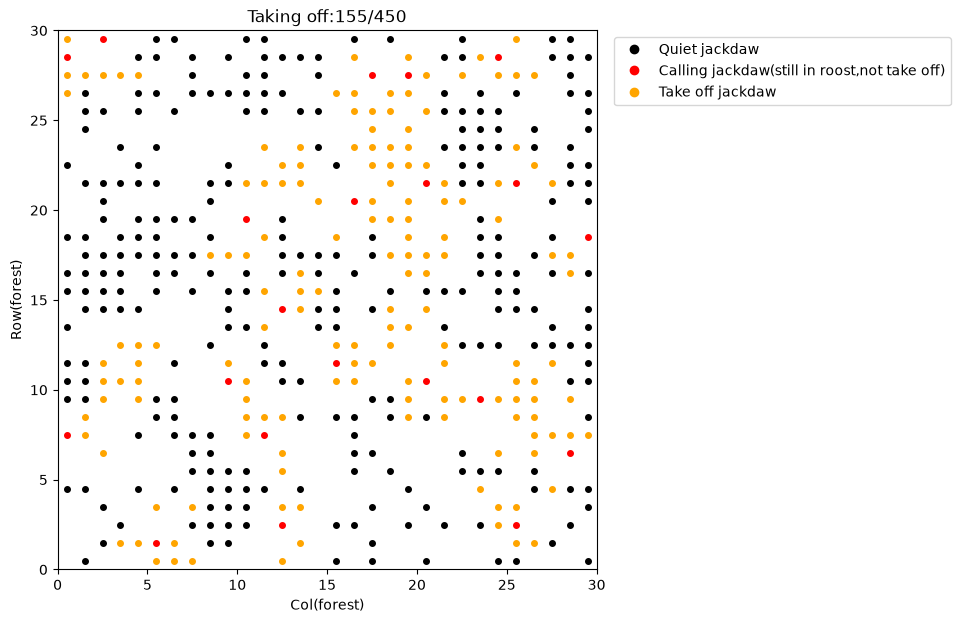

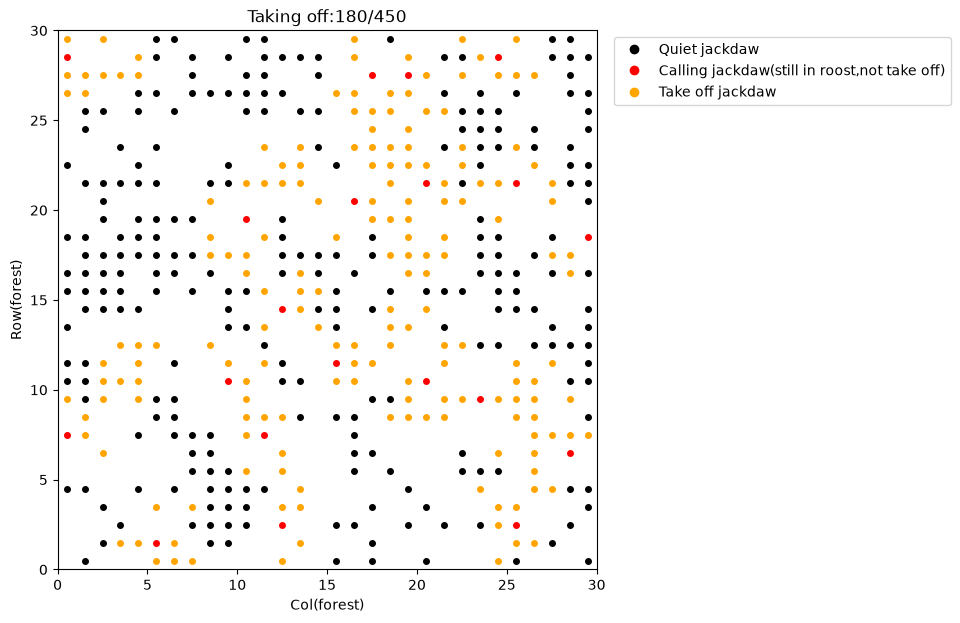

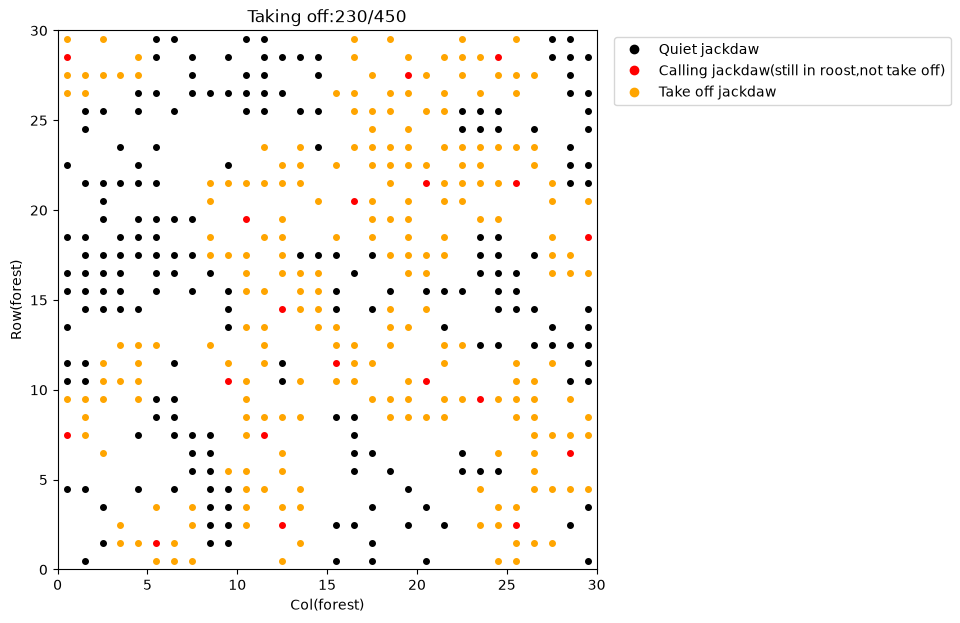

In [6]:
draw_roost(roost)

for i in range(32):
    # After 2 time step the voice of jackdaw rise 1 cell,gow slowly
    roost.step(grow_every=2)

    if roost.time in [8, 16, 32]:
        draw_roost(roost)


Model B
    Birds accumulate call signals over time to prepare their readiness.For birds are ready to take off ,it may follow nearby take off birds also take off or with a small probality take off,
    Assumptions:
        * Readiness threshold: 3 accumulated signal units.
        * Call range: start with 8 surrounding cells and increases 1 cell in every 2 time step, up to 24 cells.
        * Vision range: the cells that bird can see 8 surrounding cells.
        * Take off:  a ready bird follows a bird that took off within its vision range in the previous step.Or it has 1% chance take off. 
        * Stop calling: after take off. 

In [10]:
#Model B

np.random.seed(47)

roost_b = Roost(n=30,number_of_birds=450)

for bird in roost_b.agents:
    bird.call_cells = 8
    bird.ready_threshold = 3
    bird.vision = 1

    if np.random.random() < 0.1:
        bird.calling = True

roost_b.update_calls()
roost_b.update_takeoffs_b(start_probility=0.01)


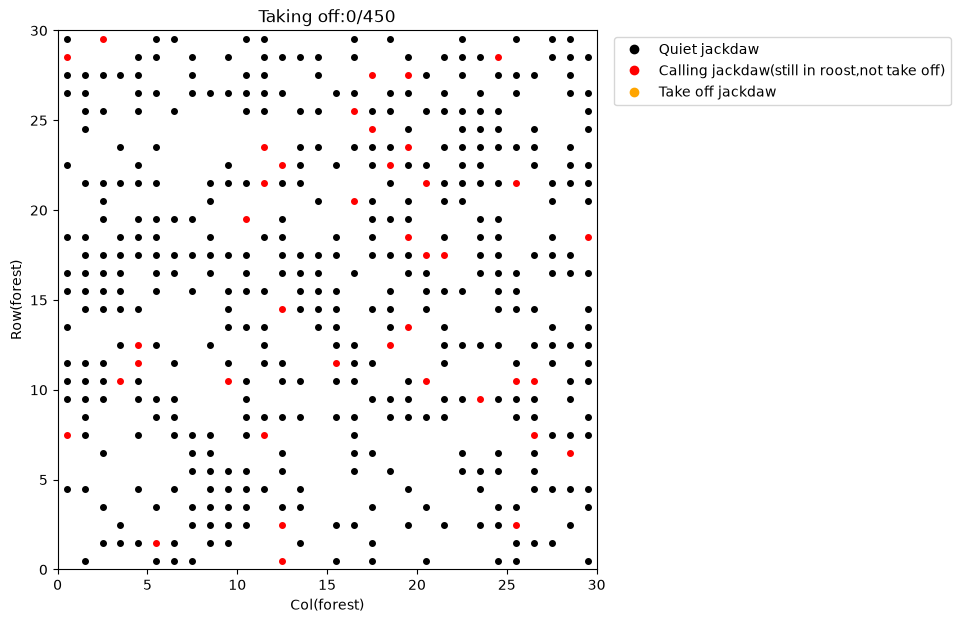

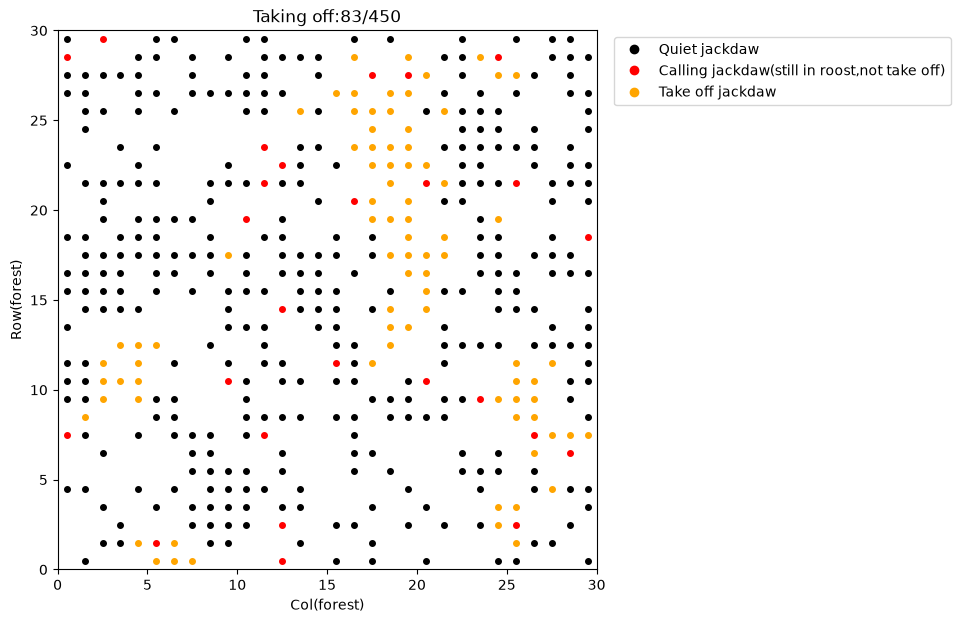

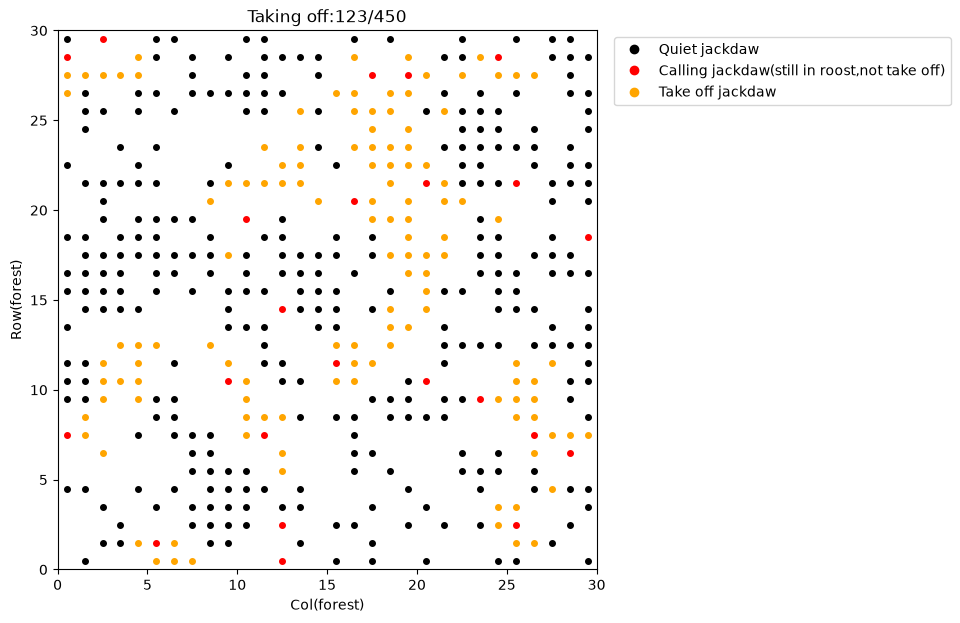

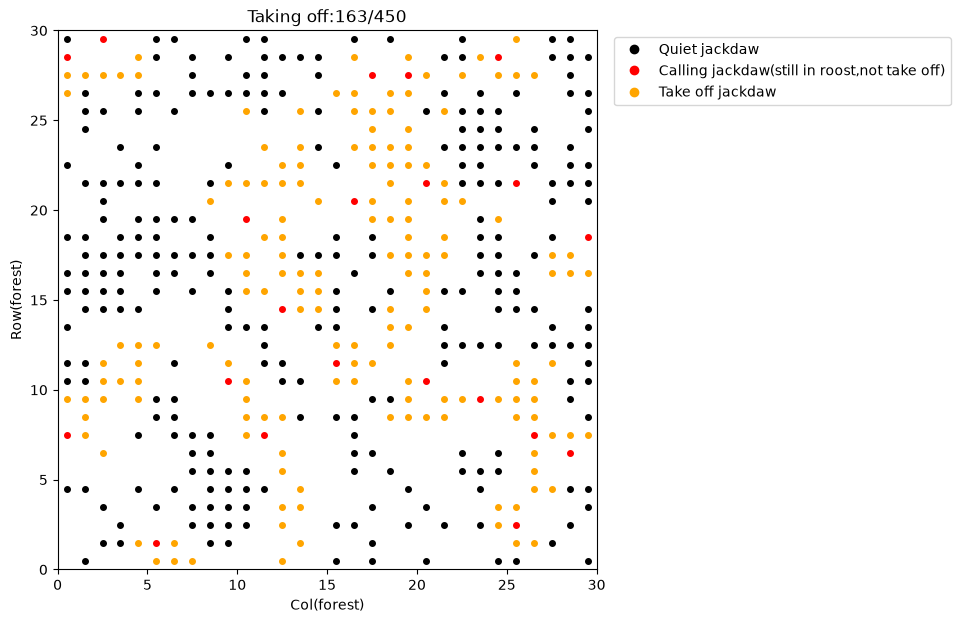

In [11]:
draw_roost(roost_b)

for i in range(32):
    roost_b.step_b(grow_every=2,start_probility=0.01)

    if roost_b.time in [8,16,32]:
        draw_roost(roost_b)

Next steps

Will test weather faster growth in call range leads to earlier depatures of jackdaws.

    1.form 8 cells slowly growth 1 cell in 2 time steps till 24 cell.
    2.from 8 cells slowly growth 1 cell in 1 time step till 24 cell.
    3.slowing down


In [4]:
#Add some calling for test

caller = roost.agents[0]
caller.calling = True
caller.call_cells = 8

roost.update_calls()
roost.update_takeoffs()

print("calling jackdaws:",caller.loc)
print("Cells receive calls:", np.count_nonzero(roost.calls))

calling jackdaws: (17, 12)
Cells receive calls: 8


In [5]:
caller.call_cells = min(caller.call_cells + 1,24)
roost.update_calls()
print("Cells receive calls:", np.count_nonzero(roost.calls))

Cells receive calls: 9


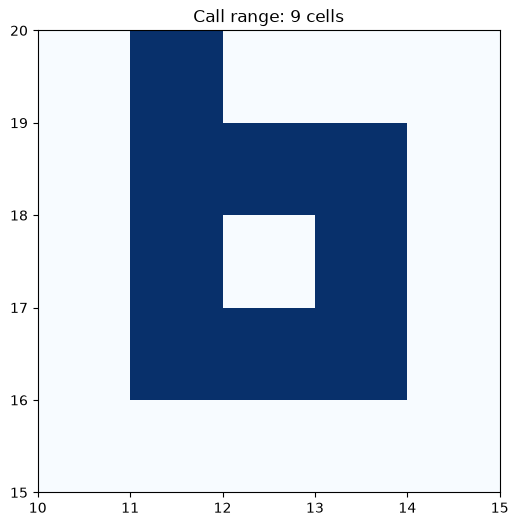

In [6]:
row,col = caller.loc

plt.figure(figsize=(6,6))

plt.imshow(
    roost.calls,
    origin="lower",
    extent=(0,roost.n,0,roost.n),
    cmap="Blues",
    vmin=0,vmax=1
)

plt.plot(
    col + 0.5, row + 0.5,
    markerfacecolor="none",
    markeredgecolor="red",
    markersize=12
)

plt.xlim(max(0,col - 2),min(roost.n,col + 3))
plt.ylim(max(0,row - 2),min(roost.n,row + 3))

covered_cells = np.count_nonzero(roost.calls)
plt.title(f"Call range: {covered_cells} cells")
          
plt.show()


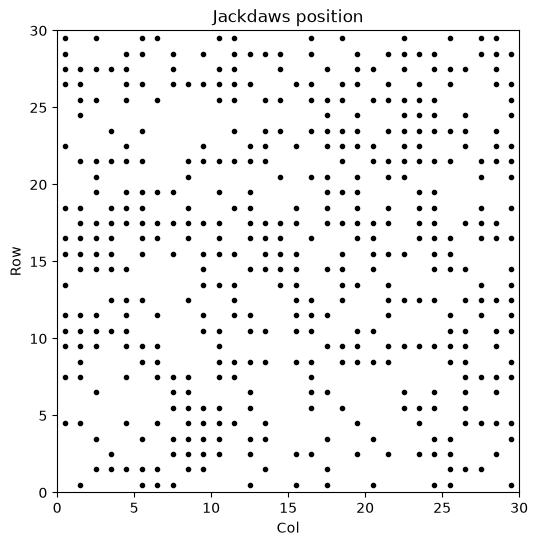

In [8]:
rows = []
cols = []

for bird in roost.agents:
    row,col = bird.loc
    rows.append(row + 0.5)
    cols.append(col + 0.5)

plt.figure(figsize=(6,6))

plt.plot(cols,rows,".",color="black")

plt.xlim(0,roost.n)
plt.ylim(0,roost.n)
plt.gca().set_aspect("equal")

plt.xlabel("Col")
plt.ylabel("Row")
plt.title("Jackdaws position")

plt.show()